<a href="https://colab.research.google.com/github/mjgpinheiro/Econophysics/blob/main/Analisador_Opcoes_IV_Gregos_Estrategia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Analisador de Opções — Vol Implícita, Gregos e Sugestão de Estratégia

**O que este notebook faz:**
1. Lê a cadeia de opções de um ticker (via **yfinance**, funciona diretamente no Colab; ou via **Interactive Brokers**, correndo localmente).
2. Calcula **volatilidade implícita** (invertendo Black-Scholes numericamente 😉) e todos os **gregos** por strike.
3. Compara vol implícita vs. **vol realizada** (o *volatility risk premium*) e mede a tendência direcional.
4. Sugere a estratégia mais adequada ao regime atual: **iron condor, strangle vendido, credit spread, straddle comprado, debit spread**, etc.
5. Constrói as pernas concretas (strikes por delta), calcula crédito/débito, breakevens, lucro/perda máximos e desenha o **diagrama de payoff**.

---
⚠️ **Aviso importante**: isto é uma ferramenta **educativa**. Não é aconselhamento financeiro. Opções envolvem risco elevado — estratégias de venda de prémio podem ter perdas muito superiores ao crédito recebido. Testa sempre em *paper trading* primeiro e valida os números de forma independente antes de arriscar dinheiro real.


In [1]:
# @title 1) Instalação de dependências { display-mode: "form" }
%pip install -q yfinance ib_async
print("Dependências instaladas ✔")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.5/348.5 kB 14.4 MB/s eta 0:00:00
Dependências instaladas ✔


In [2]:
# @title 2) Núcleo matemático: Black-Scholes, gregos e vol implícita
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from datetime import datetime, timezone

def bs_d1_d2(S, K, T, r, sigma, q=0.0):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return d1, d1 - sigma * np.sqrt(T)

def bs_price(S, K, T, r, sigma, kind="call", q=0.0):
    """Preço Black-Scholes(-Merton) de uma opção europeia."""
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0) if kind == "call" else max(K - S, 0.0)
    d1, d2 = bs_d1_d2(S, K, T, r, sigma, q)
    if kind == "call":
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

def bs_greeks(S, K, T, r, sigma, kind="call", q=0.0):
    """Gregos. Vega por 1 ponto de vol (1%); theta por dia de calendário."""
    d1, d2 = bs_d1_d2(S, K, T, r, sigma, q)
    pdf = norm.pdf(d1)
    delta = np.exp(-q*T) * (norm.cdf(d1) if kind == "call" else norm.cdf(d1) - 1)
    gamma = np.exp(-q*T) * pdf / (S * sigma * np.sqrt(T))
    vega  = S * np.exp(-q*T) * pdf * np.sqrt(T) / 100.0
    if kind == "call":
        theta = (-S*np.exp(-q*T)*pdf*sigma/(2*np.sqrt(T))
                 - r*K*np.exp(-r*T)*norm.cdf(d2)
                 + q*S*np.exp(-q*T)*norm.cdf(d1)) / 365.0
        rho = K*T*np.exp(-r*T)*norm.cdf(d2) / 100.0
    else:
        theta = (-S*np.exp(-q*T)*pdf*sigma/(2*np.sqrt(T))
                 + r*K*np.exp(-r*T)*norm.cdf(-d2)
                 - q*S*np.exp(-q*T)*norm.cdf(-d1)) / 365.0
        rho = -K*T*np.exp(-r*T)*norm.cdf(-d2) / 100.0
    return dict(delta=float(delta), gamma=float(gamma), vega=float(vega),
                theta=float(theta), rho=float(rho))

def implied_vol(price, S, K, T, r, kind="call", q=0.0):
    """A famosa 'inversão impossível' 😄 — resolve BS(σ)=preço com Brent.
    Funciona porque o preço é estritamente crescente em σ (vega>0) → solução única."""
    lo = max(S*np.exp(-q*T) - K*np.exp(-r*T), 0.0) if kind == "call" \
         else max(K*np.exp(-r*T) - S*np.exp(-q*T), 0.0)
    if not np.isfinite(price) or price <= lo + 1e-10 or T <= 0:
        return np.nan
    try:
        return brentq(lambda s: bs_price(S, K, T, r, s, kind, q) - price, 1e-4, 5.0, xtol=1e-8)
    except ValueError:
        return np.nan

# auto-teste rápido
_c = bs_price(100, 100, 0.25, 0.04, 0.30, "call")
assert abs(implied_vol(_c, 100, 100, 0.25, 0.04, "call") - 0.30) < 1e-6
print("Núcleo matemático OK ✔  (inversão de BS a funcionar, com os cumprimentos ao Marcelo)")

Núcleo matemático OK ✔  (inversão de BS a funcionar, com os cumprimentos ao Marcelo)


In [3]:
# @title 3) Configuração { display-mode: "form" }
TICKER        = "SPY"    # @param {type:"string"}
FONTE         = "yfinance"  # @param ["yfinance", "ibkr"]
DTE_ALVO      = 35       # @param {type:"integer"}  — dias até expiração alvo (30-45 é o "sweet spot" para venda de prémio)
TAXA_JURO     = 0.042    # @param {type:"number"}   — taxa sem risco anual (aprox. T-bill 3m)
DELTA_SHORT_CONDOR = 0.20   # delta das pernas vendidas do condor/strangle
DELTA_LONG_CONDOR  = 0.10   # delta das asas compradas do condor
DELTA_SHORT_SPREAD = 0.30   # delta da perna vendida em credit spreads
LARGURA_SPREAD_PCT = 0.03   # largura da asa do spread, em % do spot
print(f"Config: {TICKER}, fonte={FONTE}, DTE alvo={DTE_ALVO}, r={TAXA_JURO:.2%}")

Config: SPY, fonte=yfinance, DTE alvo=35, r=4.20%


## 4) Dados de mercado

**Duas fontes possíveis:**

- **`yfinance`** — grátis, funciona *out-of-the-box* no Colab. Cotações de opções com ~15 min de atraso. Perfeito para análise e aprendizagem.
- **`ibkr`** — dados em tempo real da tua conta Interactive Brokers, **mas** exige o TWS ou IB Gateway a correr na tua máquina. Como o Colab corre nos servidores da Google, **não consegue chegar ao teu `localhost`** — para usar IB, descarrega este notebook e corre-o localmente (`pip install jupyter && jupyter notebook`), ou usa a fonte `yfinance` no Colab. A secção IBKR está mais abaixo, pronta a usar.


In [4]:
# @title 4a) Fetch via yfinance: spot, histórico e cadeia de opções
import yfinance as yf

tk = yf.Ticker(TICKER)
hist = tk.history(period="1y", auto_adjust=True)
if hist.empty:
    raise RuntimeError(f"Sem histórico para {TICKER} — verifica o ticker.")
SPOT = float(hist["Close"].iloc[-1])

# dividend yield (para o q de Black-Scholes-Merton)
try:
    DIV_YIELD = float(tk.info.get("dividendYield") or 0.0)
    if DIV_YIELD > 1:  # yfinance às vezes devolve em %
        DIV_YIELD /= 100.0
except Exception:
    DIV_YIELD = 0.0

# escolher a expiração mais próxima do DTE alvo
hoje = pd.Timestamp.now(tz="UTC").normalize()
exps = tk.options
if not exps:
    raise RuntimeError(f"{TICKER} não tem opções listadas no yfinance.")
dtes = {e: (pd.Timestamp(e, tz="UTC") - hoje).days for e in exps}
EXPIRACAO = min(dtes, key=lambda e: abs(dtes[e] - DTE_ALVO))
DTE = max(dtes[EXPIRACAO], 1)
T = DTE / 365.0

chain = tk.option_chain(EXPIRACAO)
calls, puts = chain.calls.copy(), chain.puts.copy()

def preparar(df, kind):
    df = df[["strike", "bid", "ask", "lastPrice", "volume", "openInterest"]].copy()
    df["mid"] = np.where((df.bid > 0) & (df.ask > 0), (df.bid + df.ask)/2, df.lastPrice)
    df["kind"] = kind
    # filtrar lixo: sem preço, spreads absurdos, strikes muito longe
    df = df[(df.mid > 0.01) & (df.strike > SPOT*0.6) & (df.strike < SPOT*1.4)]
    return df

calls, puts = preparar(calls, "call"), preparar(puts, "put")
print(f"{TICKER}: spot = {SPOT:.2f} | div. yield ≈ {DIV_YIELD:.2%}")
print(f"Expiração escolhida: {EXPIRACAO} ({DTE} dias) | {len(calls)} calls, {len(puts)} puts utilizáveis")

SPY: spot = 746.86 | div. yield ≈ 1.01%
Expiração escolhida: 2026-08-14 (38 dias) | 36 calls, 34 puts utilizáveis


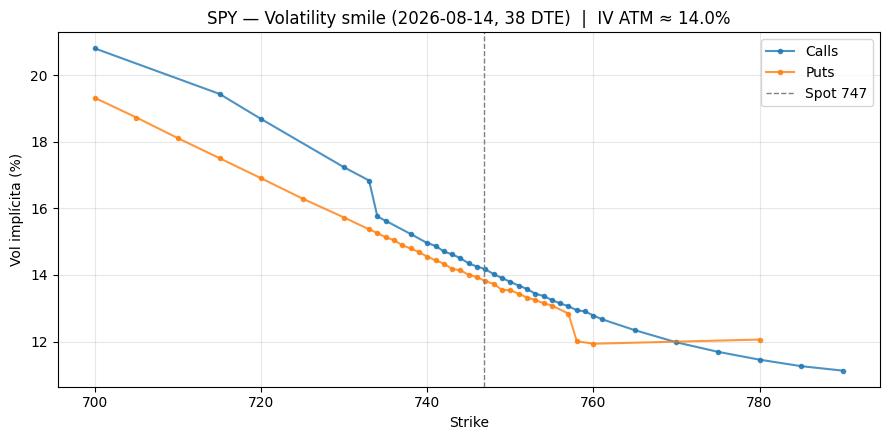

IV ATM = 13.99%  ← isto é a inversão de Black-Scholes aplicada ao mercado real


In [5]:
# @title 4b) Vol implícita e gregos por strike + smile
def enriquecer(df):
    ivs, deltas, gammas, vegas, thetas = [], [], [], [], []
    for _, row in df.iterrows():
        iv = implied_vol(row.mid, SPOT, row.strike, T, TAXA_JURO, row.kind, DIV_YIELD)
        ivs.append(iv)
        if np.isfinite(iv):
            g = bs_greeks(SPOT, row.strike, T, TAXA_JURO, iv, row.kind, DIV_YIELD)
            deltas.append(g["delta"]); gammas.append(g["gamma"])
            vegas.append(g["vega"]);   thetas.append(g["theta"])
        else:
            deltas.append(np.nan); gammas.append(np.nan); vegas.append(np.nan); thetas.append(np.nan)
    df = df.assign(iv=ivs, delta=deltas, gamma=gammas, vega=vegas, theta=thetas)
    return df.dropna(subset=["iv"])

calls, puts = enriquecer(calls), enriquecer(puts)

# IV at-the-money: média das IVs de call e put mais próximas do spot
iv_call_atm = calls.iloc[(calls.strike - SPOT).abs().argsort()[:1]].iv.mean()
iv_put_atm  = puts.iloc[(puts.strike - SPOT).abs().argsort()[:1]].iv.mean()
IV_ATM = np.nanmean([iv_call_atm, iv_put_atm])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(calls.strike, calls.iv*100, ".-", label="Calls", alpha=.8)
ax.plot(puts.strike,  puts.iv*100,  ".-", label="Puts",  alpha=.8)
ax.axvline(SPOT, color="gray", ls="--", lw=1, label=f"Spot {SPOT:.0f}")
ax.set_title(f"{TICKER} — Volatility smile ({EXPIRACAO}, {DTE} DTE)  |  IV ATM ≈ {IV_ATM:.1%}")
ax.set_xlabel("Strike"); ax.set_ylabel("Vol implícita (%)"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"IV ATM = {IV_ATM:.2%}  ← isto é a inversão de Black-Scholes aplicada ao mercado real")

In [6]:
# @title 5) Regime de mercado: vol realizada, prémio de risco de vol e direção
ret = np.log(hist["Close"] / hist["Close"].shift(1)).dropna()

RV20 = float(ret.tail(20).std() * np.sqrt(252))   # vol realizada 20 dias, anualizada
RV60 = float(ret.tail(60).std() * np.sqrt(252))

# distribuição da RV20 no último ano → percentil aproximado da IV atual
rv20_hist = (ret.rolling(20).std() * np.sqrt(252)).dropna()
IV_PCTL = float((rv20_hist < IV_ATM).mean() * 100)   # proxy: onde a IV atual cai vs. vol realizada histórica

VRP = IV_ATM - RV20            # volatility risk premium (IV - RV)
VRP_RATIO = IV_ATM / RV20 if RV20 > 0 else np.nan

# sinal direcional simples: médias móveis + momentum
sma20 = hist["Close"].rolling(20).mean().iloc[-1]
sma50 = hist["Close"].rolling(50).mean().iloc[-1]
mom20 = float(hist["Close"].iloc[-1] / hist["Close"].iloc[-21] - 1)

if SPOT > sma50 and sma20 > sma50 and mom20 > 0.01:
    DIRECAO = "bullish"
elif SPOT < sma50 and sma20 < sma50 and mom20 < -0.01:
    DIRECAO = "bearish"
else:
    DIRECAO = "neutro"

# movimento esperado até à expiração implícito na IV (1 desvio-padrão)
MOVE_ESPERADO = SPOT * IV_ATM * np.sqrt(T)

print(f"Vol realizada 20d: {RV20:.2%}   |  60d: {RV60:.2%}")
print(f"IV ATM:            {IV_ATM:.2%}")
print(f"VRP (IV − RV20):   {VRP:+.2%}   |  rácio IV/RV: {VRP_RATIO:.2f}")
print(f"Percentil da IV vs. RV histórica (proxy de IV rank): {IV_PCTL:.0f}%")
print(f"Direção (SMA20/50 + momentum): {DIRECAO.upper()}")
print(f"Movimento esperado ±1σ até {EXPIRACAO}: ±{MOVE_ESPERADO:.2f} ({MOVE_ESPERADO/SPOT:.1%})")
print("\nNota: sem histórico de IV (o yfinance não o dá), o 'IV rank' aqui é uma")
print("aproximação via vol realizada. Com IBKR ou outro fornecedor, usa IV histórica real.")

Vol realizada 20d: 15.85%   |  60d: 13.33%
IV ATM:            13.99%
VRP (IV − RV20):   -1.86%   |  rácio IV/RV: 0.88
Percentil da IV vs. RV histórica (proxy de IV rank): 73%
Direção (SMA20/50 + momentum): BULLISH
Movimento esperado ±1σ até 2026-08-14: ±33.71 (4.5%)

Nota: sem histórico de IV (o yfinance não o dá), o 'IV rank' aqui é uma
aproximação via vol realizada. Com IBKR ou outro fornecedor, usa IV histórica real.


In [7]:
# @title 6) O conselheiro: que estratégia faz sentido neste regime?
def aconselhar(vrp_ratio, iv_pctl, direcao):
    """Matriz de decisão clássica: vol cara → vender prémio; vol barata → comprar.
    Direção define se a estrutura é neutra ou enviesada."""
    iv_cara   = (vrp_ratio >= 1.15) and (iv_pctl >= 60)
    iv_barata = (vrp_ratio <= 0.90) or  (iv_pctl <= 25)

    if iv_cara and direcao == "neutro":
        return ("IRON CONDOR (vender prémio, risco definido)",
                "IV bem acima da vol realizada e sem tendência clara → vender vol dos dois lados. "
                "Theta positivo, vega negativo, gama negativo (o risco a vigiar). "
                "Alternativa mais agressiva: short strangle (sem asas, margem maior, risco ilimitado).")
    if iv_cara and direcao == "bullish":
        return ("BULL PUT SPREAD (credit spread)",
                "IV cara + viés altista → vender prémio do lado da put. Ganhas com theta E com a subida. "
                "Risco definido pela asa comprada.")
    if iv_cara and direcao == "bearish":
        return ("BEAR CALL SPREAD (credit spread)",
                "IV cara + viés baixista → vender prémio do lado da call. Risco definido.")
    if iv_barata and direcao == "neutro":
        return ("LONG STRADDLE (comprar vol)",
                "IV abaixo da vol realizada → opções 'baratas'. Compras movimento sem apostar na direção. "
                "Vega positivo, theta negativo — precisas que o movimento chegue DEPRESSA. "
                "Ideal se houver catalisador à vista (resultados, decisão de banco central).")
    if iv_barata and direcao == "bullish":
        return ("BULL CALL SPREAD (debit spread)",
                "IV barata + viés altista → comprar direção com custo reduzido. "
                "O spread reduz o custo de vega/theta face à call seca.")
    if iv_barata and direcao == "bearish":
        return ("BEAR PUT SPREAD (debit spread)",
                "IV barata + viés baixista → comprar puts em spread.")
    return ("AGUARDAR / POSIÇÃO PEQUENA",
            "IV em linha com a vol realizada e sem edge claro. Sem prémio gordo para vender "
            "nem vol barata para comprar — o melhor trade é muitas vezes não fazer trade. "
            "Se insistires, usa estruturas de risco definido e tamanho reduzido.")

ESTRATEGIA, JUSTIFICACAO = aconselhar(VRP_RATIO, IV_PCTL, DIRECAO)
print("═" * 70)
print(f"  SUGESTÃO: {ESTRATEGIA}")
print("═" * 70)
print(JUSTIFICACAO)

══════════════════════════════════════════════════════════════════════
  SUGESTÃO: BULL CALL SPREAD (debit spread)
══════════════════════════════════════════════════════════════════════
IV barata + viés altista → comprar direção com custo reduzido. O spread reduz o custo de vega/theta face à call seca.


── BULL CALL SPREAD (debit spread) em SPY, expiração 2026-08-14 (38 DTE) ──

  COMPRAR  1x CALL strike   750.00  @  12.93  (Δ=+0.50)
  VENDER   1x CALL strike   770.00  @   4.15  (Δ=+0.25)

  DÉBITO pago: 877.50 USD por estrutura
  Lucro máx.:     1122.50 USD
  Perda máx.:     -877.50 USD
  Rácio risco/retorno: 1.28
  Breakevens: 758.77  (spot: 746.86)

  Gregos líquidos (1 estrutura): Δ=+25.4  vega=+20.0 USD/ponto de vol  theta=-7.0 USD/dia


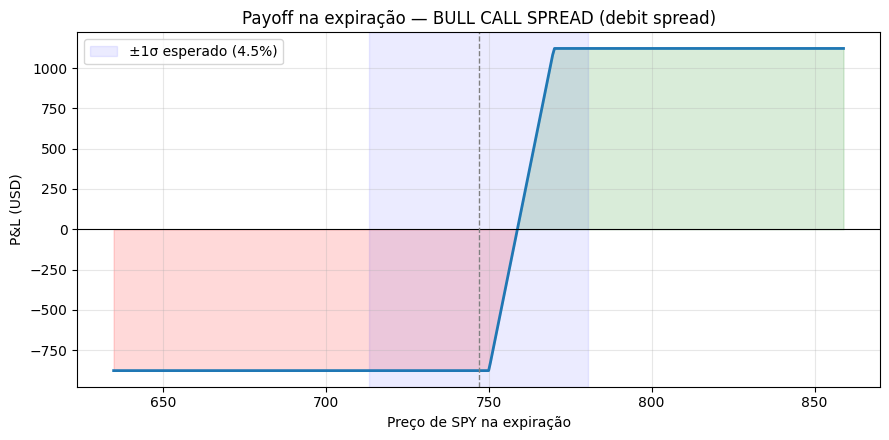

In [8]:
# @title 7) Construir as pernas, P&L e diagrama de payoff
def strike_por_delta(df, alvo, kind):
    """Encontra o strike cujo |delta| está mais próximo do alvo."""
    d = df.delta.abs()
    return df.iloc[(d - alvo).abs().argsort()[:1]].iloc[0]

def leg(row, lado, qty=1):
    return dict(kind=row.kind, strike=float(row.strike), mid=float(row.mid),
                delta=float(row.delta), lado=lado, qty=qty)

def montar_estrategia(nome):
    legs = []
    if "IRON CONDOR" in nome:
        sc = strike_por_delta(calls, DELTA_SHORT_CONDOR, "call")
        sp = strike_por_delta(puts,  DELTA_SHORT_CONDOR, "put")
        lc = strike_por_delta(calls[calls.strike > sc.strike], DELTA_LONG_CONDOR, "call")
        lp = strike_por_delta(puts[puts.strike < sp.strike],   DELTA_LONG_CONDOR, "put")
        legs = [leg(sp,"vender"), leg(lp,"comprar"), leg(sc,"vender"), leg(lc,"comprar")]
    elif "BULL PUT" in nome:
        s = strike_por_delta(puts, DELTA_SHORT_SPREAD, "put")
        alvo_l = s.strike - SPOT*LARGURA_SPREAD_PCT
        l = puts.iloc[(puts.strike - alvo_l).abs().argsort()[:1]].iloc[0]
        legs = [leg(s,"vender"), leg(l,"comprar")]
    elif "BEAR CALL" in nome:
        s = strike_por_delta(calls, DELTA_SHORT_SPREAD, "call")
        alvo_l = s.strike + SPOT*LARGURA_SPREAD_PCT
        l = calls.iloc[(calls.strike - alvo_l).abs().argsort()[:1]].iloc[0]
        legs = [leg(s,"vender"), leg(l,"comprar")]
    elif "STRADDLE" in nome:
        c = calls.iloc[(calls.strike - SPOT).abs().argsort()[:1]].iloc[0]
        p = puts.iloc[(puts.strike - SPOT).abs().argsort()[:1]].iloc[0]
        legs = [leg(c,"comprar"), leg(p,"comprar")]
    elif "BULL CALL" in nome:
        lc = strike_por_delta(calls, 0.50, "call")
        alvo_s = lc.strike + SPOT*LARGURA_SPREAD_PCT
        sc = calls.iloc[(calls.strike - alvo_s).abs().argsort()[:1]].iloc[0]
        legs = [leg(lc,"comprar"), leg(sc,"vender")]
    elif "BEAR PUT" in nome:
        lp = strike_por_delta(puts, 0.50, "put")
        alvo_s = lp.strike - SPOT*LARGURA_SPREAD_PCT
        sp = puts.iloc[(puts.strike - alvo_s).abs().argsort()[:1]].iloc[0]
        legs = [leg(lp,"comprar"), leg(sp,"vender")]
    return legs

def payoff_expiracao(legs, S_range):
    pnl = np.zeros_like(S_range, dtype=float)
    for L in legs:
        intr = np.maximum(S_range - L["strike"], 0) if L["kind"]=="call" \
               else np.maximum(L["strike"] - S_range, 0)
        sinal = -1 if L["lado"]=="vender" else 1
        pnl += sinal * (intr - L["mid"]) * L["qty"]
    return pnl * 100   # 1 contrato = 100 ações

LEGS = montar_estrategia(ESTRATEGIA)
if not LEGS:
    print("Regime 'aguardar' — sem pernas para montar. Volta noutro dia. 🙂")
else:
    fluxo = sum((L["mid"] if L["lado"]=="vender" else -L["mid"]) for L in LEGS) * 100
    tipo_fluxo = "CRÉDITO recebido" if fluxo > 0 else "DÉBITO pago"

    print(f"── {ESTRATEGIA} em {TICKER}, expiração {EXPIRACAO} ({DTE} DTE) ──\n")
    for L in LEGS:
        print(f"  {L['lado'].upper():8s} 1x {L['kind'].upper():4s} strike {L['strike']:>8.2f}  "
              f"@ {L['mid']:>6.2f}  (Δ={L['delta']:+.2f})")
    print(f"\n  {tipo_fluxo}: {abs(fluxo):.2f} USD por estrutura")

    S_grid = np.linspace(SPOT*0.85, SPOT*1.15, 400)
    pnl = payoff_expiracao(LEGS, S_grid)
    max_p, max_l = pnl.max(), pnl.min()
    # breakevens
    sinais = np.sign(pnl); cruz = np.where(np.diff(sinais) != 0)[0]
    bes = [float(S_grid[i] - pnl[i]*(S_grid[i+1]-S_grid[i])/(pnl[i+1]-pnl[i])) for i in cruz]

    print(f"  Lucro máx.:  {max_p:>10.2f} USD")
    print(f"  Perda máx.:  {max_l:>10.2f} USD" + ("  ⚠️ teoricamente ilimitada" if "STRANGLE" in ESTRATEGIA else ""))
    if max_l != 0:
        print(f"  Rácio risco/retorno: {abs(max_p/max_l):.2f}")
    if bes:
        print(f"  Breakevens: {', '.join(f'{b:.2f}' for b in bes)}  (spot: {SPOT:.2f})")

    # delta / vega / theta líquidos da estrutura
    net = {"delta":0.0, "vega":0.0, "theta":0.0}
    for L in LEGS:
        row = (calls if L["kind"]=="call" else puts)
        row = row.iloc[(row.strike - L["strike"]).abs().argsort()[:1]].iloc[0]
        s = -1 if L["lado"]=="vender" else 1
        net["delta"] += s*row.delta*100; net["vega"] += s*row.vega*100; net["theta"] += s*row.theta*100
    print(f"\n  Gregos líquidos (1 estrutura): Δ={net['delta']:+.1f}  "
          f"vega={net['vega']:+.1f} USD/ponto de vol  theta={net['theta']:+.1f} USD/dia")

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(S_grid, pnl, lw=2)
    ax.fill_between(S_grid, pnl, 0, where=pnl>=0, alpha=.15, color="green")
    ax.fill_between(S_grid, pnl, 0, where=pnl<0,  alpha=.15, color="red")
    ax.axhline(0, color="k", lw=.8); ax.axvline(SPOT, color="gray", ls="--", lw=1)
    ax.axvspan(SPOT-MOVE_ESPERADO, SPOT+MOVE_ESPERADO, alpha=.08, color="blue",
               label=f"±1σ esperado ({MOVE_ESPERADO/SPOT:.1%})")
    ax.set_title(f"Payoff na expiração — {ESTRATEGIA}")
    ax.set_xlabel(f"Preço de {TICKER} na expiração"); ax.set_ylabel("P&L (USD)")
    ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 8) Ligação ao Interactive Brokers (opcional)

Para usar dados reais da tua conta IB (e eventualmente enviar ordens):

1. Instala e abre o **TWS** ou o **IB Gateway** na tua máquina.
2. Em *File → Global Configuration → API → Settings*: ativa **Enable ActiveX and Socket Clients**, aponta a porta (7497 = TWS paper, 7496 = TWS live, 4002 = Gateway paper, 4001 = Gateway live) e, idealmente, deixa **Read-Only API** ligado enquanto testas.
3. ⚠️ **No Colab isto não funciona** — o Colab corre na Google e não vê o teu `localhost`. Descarrega o notebook (*File → Download → .ipynb*) e corre-o localmente com Jupyter.
4. Começa **sempre** com a conta *paper* (porta 7497/4002).

A célula seguinte lê a cadeia com a IV e os gregos calculados pelo próprio IB e injeta-os no pipeline acima. A última célula mostra como **enviaria** uma ordem combo — está deliberadamente comentada.


In [9]:
# @title 8a) Fetch via IBKR (correr localmente com TWS/Gateway aberto)
USAR_IBKR = (FONTE == "ibkr")

if USAR_IBKR:
    from ib_async import IB, Stock, Option, util
    util.startLoop()  # necessário dentro de Jupyter

    ib = IB()
    ib.connect("127.0.0.1", 7497, clientId=17)   # 7497 = TWS paper trading

    stk = Stock(TICKER, "SMART", "USD")
    ib.qualifyContracts(stk)
    [tick] = ib.reqTickers(stk)
    SPOT = tick.marketPrice()
    print(f"Spot IB: {SPOT:.2f}")

    # cadeias disponíveis → escolher expiração mais próxima do DTE alvo
    chains = ib.reqSecDefOptParams(stk.symbol, "", stk.secType, stk.conId)
    ch = next(c for c in chains if c.exchange == "SMART")
    hoje = pd.Timestamp.now().normalize()
    exp_dtes = {e: (pd.Timestamp(e) - hoje).days for e in ch.expirations}
    EXPIRACAO_IB = min(exp_dtes, key=lambda e: abs(exp_dtes[e] - DTE_ALVO))
    DTE = max(exp_dtes[EXPIRACAO_IB], 1); T = DTE/365.0
    strikes = [k for k in ch.strikes if SPOT*0.8 < k < SPOT*1.2]

    contratos = [Option(TICKER, EXPIRACAO_IB, k, d, "SMART", tradingClass=ch.tradingClass)
                 for k in strikes for d in ("C", "P")]
    contratos = ib.qualifyContracts(*contratos)
    tickers = ib.reqTickers(*contratos)   # traz modelGreeks do IB

    rows = []
    for t in tickers:
        g = t.modelGreeks
        if g is None or t.midpoint() != t.midpoint():
            continue
        rows.append(dict(strike=t.contract.strike,
                         kind="call" if t.contract.right == "C" else "put",
                         mid=t.midpoint(), iv=g.impliedVol, delta=g.delta,
                         gamma=g.gamma, vega=g.vega, theta=g.theta,
                         bid=t.bid, ask=t.ask, volume=t.volume, openInterest=0))
    df_ib = pd.DataFrame(rows)
    calls = df_ib[df_ib.kind == "call"].sort_values("strike").reset_index(drop=True)
    puts  = df_ib[df_ib.kind == "put"].sort_values("strike").reset_index(drop=True)
    EXPIRACAO = EXPIRACAO_IB
    print(f"Cadeia IB carregada: {len(calls)} calls, {len(puts)} puts — "
          f"volta a correr as células 4b→7 para usar estes dados.")
else:
    print("FONTE = 'yfinance' — célula IBKR ignorada. Muda FONTE para 'ibkr' e corre localmente.")

FONTE = 'yfinance' — célula IBKR ignorada. Muda FONTE para 'ibkr' e corre localmente.


In [10]:
# @title 8b) Envio de ordem combo ao IB (EXEMPLO — deliberadamente comentado)
# ⚠️ NUNCA descomentes isto sem: (1) estares na conta PAPER, (2) teres revisto
# cada perna, (3) perceberes a margem exigida. Ordens de opções executam em segundos.
#
# if USAR_IBKR and LEGS:
#     from ib_async import Contract, ComboLeg, Order
#
#     combo = Contract(symbol=TICKER, secType="BAG", currency="USD", exchange="SMART")
#     combo.comboLegs = []
#     for L in LEGS:
#         right = "C" if L["kind"] == "call" else "P"
#         opt = Option(TICKER, EXPIRACAO, L["strike"], right, "SMART")
#         ib.qualifyContracts(opt)
#         combo.comboLegs.append(ComboLeg(conId=opt.conId, ratio=1,
#                                         action="SELL" if L["lado"]=="vender" else "BUY",
#                                         exchange="SMART"))
#     # ordem limite ao mid líquido da estrutura (crédito → preço negativo no IB p/ BAG)
#     lim = round(sum((-L["mid"] if L["lado"]=="vender" else L["mid"]) for L in LEGS), 2)
#     ordem = Order(action="BUY", orderType="LMT", totalQuantity=1, lmtPrice=lim, tif="DAY")
#     trade = ib.placeOrder(combo, ordem)
#     print(trade)
print("Exemplo de ordem disponível no código (comentado por segurança).")

Exemplo de ordem disponível no código (comentado por segurança).


## Limitações e próximos passos

**Limitações honestas desta versão:**
- O "IV rank" via yfinance é uma **aproximação** baseada na vol realizada histórica (o yfinance não dá histórico de IV). Com IB ou um fornecedor de dados de vol, substitui pela IV histórica real.
- O sinal direcional (médias móveis + momentum) é propositadamente simples — é um ponto de partida, não um sistema.
- Preços `mid` do yfinance podem estar desfasados ~15 min e alguns strikes ilíquidos têm spreads enormes (o filtro remove os piores casos).
- O modelo é Black-Scholes-Merton europeu; opções americanas sobre ações individuais com dividendos têm pequenos desvios (para índices/ETFs como SPY, a diferença é geralmente pequena).
- **Probabilidade de lucro, gestão da posição (rolar, fechar a 50% do crédito, stops) e dimensionamento não estão incluídos** — e são metade do jogo.

**Ideias para expandir:** backtesting das regras, term structure de IV (comparar várias expirações), skew de 25-delta como sinal, gestão automática de posições abertas via IB, alertas.

---
*Ferramenta educativa. Nada aqui é aconselhamento financeiro. E sim, Marcelo: a equação inverte-se — a célula 2 fá-lo em microssegundos.* 😉
